# Reproduce: Bat4RCT — Text Classification of Randomized Controlled Trials

**Paper gốc:** Kim, J., Kim, J., Lee, A., & Kim, J. (2023). *Bat4RCT: A suite of benchmark data and baseline methods for text classification of randomized controlled trials.* **PLOS ONE**, 18(3): e0283342. https://doi.org/10.1371/journal.pone.0283342
**Code & data gốc:** https://github.com/jennak22/Bat4RCT (GPL-3.0)

---

### Mục tiêu reproduce
Bài toán: **phân loại nhị phân văn bản y sinh** — một bài báo MEDLINE có phải Randomized Controlled Trial (RCT) hay không, dựa trên *title* / *abstract* / *title+abstract*.

Notebook này tái hiện pipeline gốc và **xác minh các kết luận chính** của paper:
1. Các mô hình BERT (BERT, BioBERT, SciBERT) **vượt trội** baseline ML cổ điển (LR/SVM/GB) và CNN, chủ yếu nhờ **recall cao hơn đáng kể**.
2. **BioBERT + (title+abstract)** đạt F1 tốt nhất (~90.85% trên full test set của paper).
3. (Mục 3.2 của paper) Mô hình BERT **ổn định với mẫu nhỏ**, trong khi ML cổ điển phụ thuộc nhiều vào kích thước dữ liệu.

### Khác biệt có chủ đích so với bản gốc (và lý do)
| Khía cạnh | Bản gốc | Bản reproduce | Lý do |
|---|---|---|---|
| Kích thước dữ liệu | 499,963 records | sub-sample cấu hình được (mặc định 20k), **giữ tỉ lệ lớp 1:4** | Phù hợp Colab T4 free; đề bài cho phép lấy sample nhỏ hơn |
| Hạ tầng | AWS SageMaker (V100/T4) | Colab T4 (1 GPU) | Tài nguyên sinh viên |
| ML cổ điển | LR, SVM, GB | LR, **LinearSVC**, GB | `LinearSVC` thay `SVC` để khả thi về thời gian; xu hướng tương đương |
| Số mô hình BERT chạy mặc định | 3 | cấu hình được (mặc định BioBERT + SciBERT) | Tiết kiệm thời gian; có thể bật cả 3 |

> **Lưu ý trung thực:** vì ta dùng *subset* nên con số tuyệt đối sẽ lệch so với bảng full-data của paper. Mục tiêu reproduce ở đây là **tái hiện đúng xu hướng & kết luận**, không phải khớp tuyệt đối từng chữ số — đúng tinh thần đề bài ("lấy sample nhỏ hơn").


## 0. Cài đặt môi trường
Chạy cell này đầu tiên. Nếu Colab yêu cầu restart sau khi cài, restart rồi chạy lại từ Cell 1 (không cần chạy lại Cell 0).

In [ ]:
# Cell 0 — Dependencies
!pip install -q "transformers>=4.30,<5" "datasets>=2.14" scikit-learn nltk matplotlib pandas numpy tqdm
import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print("nltk download warn:", pkg, e)
print("Done installing.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.9 MB/s eta 0:00:00
Done installing.


## 1. Tải dataset gốc về (tự động)

Dataset gốc nằm trong repo dưới dạng `rct_data.zip` (Git **LFS**). Vì là LFS, link `raw.githubusercontent.com` thông thường chỉ trả về *pointer* chứ không phải file thật — phải tải qua **`media.githubusercontent.com`**.

Cell dưới thử lần lượt vài nguồn và tự kiểm tra tính hợp lệ của file zip. Toàn bộ **full dataset (~500k records)** sẽ được tải về; việc lấy sample diễn ra ở Cell 3.

In [ ]:
import os, subprocess, zipfile, sys

DATA_ZIP = "rct_data.zip"
DATA_TXT = os.path.join("rct_data", "rct_data.txt")

# Các URL ứng viên: media.* phục vụ nội dung LFS thật
URLS = [
    "https://media.githubusercontent.com/media/jennak22/Bat4RCT/main/rct_data.zip",
    "https://github.com/jennak22/Bat4RCT/raw/main/rct_data.zip",
]

def is_valid_zip(path):
    return os.path.exists(path) and zipfile.is_zipfile(path) and os.path.getsize(path) > 1_000_000

if not is_valid_zip(DATA_ZIP):
    for url in URLS:
        print(f"Đang thử tải: {url}")
        # -L theo redirect, -f fail on error
        subprocess.run(["wget", "-q", "-O", DATA_ZIP, url])
        if is_valid_zip(DATA_ZIP):
            print(f"  -> OK, kích thước {os.path.getsize(DATA_ZIP)/1e6:.1f} MB")
            break
        else:
            print("  -> không hợp lệ (có thể là LFS pointer), thử nguồn khác...")

assert is_valid_zip(DATA_ZIP), (
    "Không tải được dataset tự động. Tải thủ công 'rct_data.zip' từ "
    "https://github.com/jennak22/Bat4RCT (nút Download, vì là Git LFS) rồi upload vào Colab."
)

with zipfile.ZipFile(DATA_ZIP) as z:
    z.extractall(".")
print("Đã giải nén. Files:", [f for f in os.listdir('.') if f.startswith('rct_data')])
assert os.path.exists(DATA_TXT), "Không thấy rct_data.txt sau khi giải nén."
print("Kích thước rct_data.txt: %.1f MB" % (os.path.getsize(DATA_TXT)/1e6))

Đang thử tải: https://media.githubusercontent.com/media/jennak22/Bat4RCT/main/rct_data.zip
  -> OK, kích thước 283.5 MB
Đã giải nén. Files: ['rct_data.zip', 'rct_data']
Kích thước rct_data.txt: 802.5 MB


## 2. Nạp & kiểm tra dữ liệu

Schema gốc (theo `modules.py` của tác giả) là **TSV không header**, 5 cột:
`pmid \t pubtype \t year \t title \t abstract`, trong đó `pubtype` là nhãn (1 = RCT, 0 = non-RCT).

In [ ]:
import pandas as pd, numpy as np

COLS = ["pmid", "pubtype", "year", "title", "abstract"]
df = pd.read_csv(DATA_TXT, sep="\t", encoding="utf-8", header=None, names=COLS,
                 dtype={"pmid": str}, on_bad_lines="skip")

# Làm sạch tối thiểu giống tác giả: strip, drop null, drop duplicate pmid
df["title"]    = df["title"].astype(str).str.strip()
df["abstract"] = df["abstract"].astype(str).str.strip()
df = df.dropna(subset=["title", "abstract", "pubtype"])
df = df[df["pubtype"].isin([0, 1])]
df["pubtype"] = df["pubtype"].astype(int)
df = df.drop_duplicates(subset=["pmid"], keep="first").reset_index(drop=True)

print("Tổng số records:", len(df))
print("\nPhân bố nhãn (0=non-RCT, 1=RCT):")
print(df["pubtype"].value_counts())
print("\nTỉ lệ RCT: %.3f" % df["pubtype"].mean())
df.head(3)

Tổng số records: 499963

Phân bố nhãn (0=non-RCT, 1=RCT):
pubtype
0    399977
1     99986
Name: count, dtype: int64

Tỉ lệ RCT: 0.200


,pmid,pubtype,year,title,abstract
0,18439781,0,2011,Two patients subdued with a TASER® device: cas...,"In the United States, an increasing number of ..."
1,18468833,0,2011,A case of Takayasu arteritis causing subclavia...,The American Heart Association website defines...
2,18481181,0,2012,Pathophysiology of hypopituitarism in the sett...,The complex pathophysiology of traumatic brain...


## 3. Lấy sample (cấu hình được) — giữ nguyên tỉ lệ lớp

Paper dùng tỉ lệ ~**1 RCT : 4 non-RCT** (100k vs 400k). Ta **stratified-sample** để giữ đúng tỉ lệ này, đảm bảo phân phối lớp không bị méo.

Chỉnh `SAMPLE_SIZE` tuỳ ngân sách thời gian:
- `10000` — nhanh (~10–15 phút cho 2 model BERT)
- `20000` — mặc định, cân bằng
- `None` — dùng **full dataset** (chỉ nên chạy nếu có Colab Pro / nhiều thời gian)

In [ ]:
# Cell 3 — Stratified sampling
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 20000     # đặt None để dùng full dataset
SEED        = 42

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    frac = SAMPLE_SIZE / len(df)
    df_s, _ = train_test_split(df, train_size=frac, stratify=df["pubtype"], random_state=SEED)
    df_s = df_s.reset_index(drop=True)
else:
    df_s = df.copy()

print("Số records dùng:", len(df_s))
print(df_s["pubtype"].value_counts())
print("Tỉ lệ RCT giữ được: %.3f" % df_s["pubtype"].mean())

Số records dùng: 20000
pubtype
0    16000
1     4000
Name: count, dtype: int64
Tỉ lệ RCT giữ được: 0.200


## 4. Tách train/val/test (80/10/10, stratified)

Giống paper: chia 80/10/10 với seed cố định. Ta tạo sẵn 3 biến thể input text: `title`, `abstract`, `mix` (title + ' ' + abstract).

In [ ]:
# Cell 4 — Splits + text variants
def make_text(frame, kind):
    if kind == "title":    return frame["title"].tolist()
    if kind == "abstract": return frame["abstract"].tolist()
    if kind == "mix":      return (frame["title"] + " " + frame["abstract"]).tolist()
    raise ValueError(kind)

train_df, tmp_df = train_test_split(df_s, test_size=0.20, stratify=df_s["pubtype"], random_state=SEED)
val_df,  test_df = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df["pubtype"], random_state=SEED)
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(d):6d}  (RCT ratio {d['pubtype'].mean():.3f})")

y_train = train_df["pubtype"].values
y_val   = val_df["pubtype"].values
y_test  = test_df["pubtype"].values

train:  16000  (RCT ratio 0.200)
val  :   2000  (RCT ratio 0.200)
test :   2000  (RCT ratio 0.200)


## 5. Baseline 1 — Heuristic (keyword matching)

Tái hiện baseline đơn giản nhất của paper: gán nhãn 1 (RCT) nếu text chứa bất kỳ từ khoá nào trong danh sách (khớp chính xác, không phân biệt hoa thường). Đây là cận dưới để so sánh.

Danh sách từ khoá theo tinh thần Table 2 của paper (các cụm đặc trưng RCT).

In [ ]:
# Cell 5 — Heuristic keyword classifier
import re
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

RCT_KEYWORDS = [
    "randomized controlled trial", "randomised controlled trial",
    "randomized clinical trial", "randomised clinical trial",
    "randomly assigned", "randomly allocated", "randomization", "randomisation",
    "double-blind", "double blind", "single-blind", "placebo-controlled",
    "placebo controlled", "randomized trial", "randomised trial",
]
_pat = re.compile("|".join(re.escape(k) for k in RCT_KEYWORDS), flags=re.IGNORECASE)

def heuristic_predict(texts):
    return np.array([1 if _pat.search(t or "") else 0 for t in texts])

def report(y_true, y_pred, name):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    print(f"{name:28s} | Acc {acc*100:6.2f} | P {p*100:6.2f} | R {r*100:6.2f} | F1 {f*100:6.2f}")
    return {"model": name, "accuracy": acc, "precision": p, "recall": r, "f1": f}

results = []
for kind in ["title", "abstract", "mix"]:
    yp = heuristic_predict(make_text(test_df, kind))
    results.append(report(y_test, yp, f"Heuristic [{kind}]"))

Heuristic [title]            | Acc  85.55 | P  95.12 | R  29.25 | F1  44.74
Heuristic [abstract]         | Acc  89.15 | P  86.17 | R  54.50 | F1  66.77
Heuristic [mix]              | Acc  90.55 | P  87.54 | R  61.50 | F1  72.25


## 6. Baseline 2 — ML cổ điển (TF-IDF + LR / LinearSVC / GB)

Tiền xử lý theo paper **chỉ áp dụng cho ML cổ điển**: lowercase → tokenize (NLTK) → bỏ punctuation & stopwords → Porter stemming → TF-IDF. (Các mô hình BERT **không** dùng tiền xử lý này.)

> `LinearSVC` được dùng thay cho `SVC` kernel-RBF của bản gốc để khả thi về thời gian trên CPU; đây là lựa chọn chuẩn cho text classification chiều cao và cho xu hướng tương đương.

In [ ]:
# Cell 6 — Classical ML
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier

_stop = set(stopwords.words("english"))
_stem = PorterStemmer()

def preprocess(text):
    text = str(text).lower()
    toks = word_tokenize(text)
    toks = [_stem.stem(t) for t in toks if t.isalpha() and t not in _stop]
    return " ".join(toks)

CLASSICAL_TEXT = "mix"   # đổi sang "title"/"abstract" nếu muốn
print(f"Tiền xử lý text ({CLASSICAL_TEXT}) cho ML cổ điển ...")
Xtr_raw = [preprocess(t) for t in make_text(train_df, CLASSICAL_TEXT)]
Xte_raw = [preprocess(t) for t in make_text(test_df,  CLASSICAL_TEXT)]

vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
Xtr = vec.fit_transform(Xtr_raw)
Xte = vec.transform(Xte_raw)
print("TF-IDF shape:", Xtr.shape)

classical = {
    "LogReg":    LogisticRegression(max_iter=100, C=1.0),
    "LinearSVC": LinearSVC(C=1.0),
    "GradBoost": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1),
}
for name, clf in classical.items():
    clf.fit(Xtr, y_train)
    yp = clf.predict(Xte)
    results.append(report(y_test, yp, f"{name} [{CLASSICAL_TEXT}]"))

Tiền xử lý text (mix) cho ML cổ điển ...
TF-IDF shape: (16000, 50000)
LogReg [mix]                 | Acc  92.85 | P  89.06 | R  73.25 | F1  80.38
LinearSVC [mix]              | Acc  93.20 | P  85.11 | R  80.00 | F1  82.47
GradBoost [mix]              | Acc  94.75 | P  88.71 | R  84.50 | F1  86.56


## 7. Mô hình BERT (fine-tuning)

Cấu hình theo paper: **lr = 2e-5, batch = 16, epochs = 4, optimizer = AdamW, loss = BCE/CE**; `max_len = 150` cho title, `512` cho abstract/mix. Để tiết kiệm thời gian trên T4 free, mặc định:
- `MAX_LEN = 256` cho `mix` (đủ phủ phần lớn abstract; có thể nâng lên 512 nếu cần khớp paper sát hơn — chậm hơn ~2x)
- `EPOCHS = 3` (paper dùng 4; chênh lệch nhỏ)

Tên model trên HuggingFace (đã xác minh):
- BERT → `bert-base-cased`
- BioBERT → `dmis-lab/biobert-base-cased-v1.1`
- SciBERT → `allenai/scibert_scivocab_cased`

In [ ]:
# Cell 7a — Config + Dataset class
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ---- Cấu hình BERT ----
BERT_TEXT = "mix"        # title / abstract / mix
MAX_LEN   = 256          # paper: 150 (title) hoặc 512 (abstract/mix)
BATCH     = 16
EPOCHS    = 4            # paper: 4
LR        = 2e-5

MODELS_TO_RUN = {
    "BioBERT": "dmis-lab/biobert-base-cased-v1.1",
    "SciBERT": "allenai/scibert_scivocab_cased",
    "BERT":  "bert-base-cased",   # bỏ comment để chạy cả 3 như paper
}

class RCTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts; self.labels = labels
        self.tok = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], truncation=True, padding="max_length",
                       max_length=self.max_len, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": torch.tensor(self.labels[i], dtype=torch.long)}

train_texts = make_text(train_df, BERT_TEXT)
val_texts   = make_text(val_df,   BERT_TEXT)
test_texts  = make_text(test_df,  BERT_TEXT)

Device: cuda
GPU: Tesla T4


In [ ]:
# Cell 7b — Train / eval loop
from tqdm.auto import tqdm

def run_epoch(model, loader, optimizer=None, scheduler=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss = 0.0
    preds_all, labels_all = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, leave=False):
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            lab  = batch["labels"].to(device)
            out  = model(input_ids=ids, attention_mask=mask, labels=lab)
            loss = out.loss
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
            total_loss += loss.item()
            preds_all.extend(out.logits.argmax(-1).cpu().numpy())
            labels_all.extend(lab.cpu().numpy())
    return total_loss/len(loader), np.array(labels_all), np.array(preds_all)

def fine_tune(model_name):
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

    tr_loader = DataLoader(RCTDataset(train_texts, y_train, tok, MAX_LEN), batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(RCTDataset(val_texts,   y_val,   tok, MAX_LEN), batch_size=BATCH)
    te_loader = DataLoader(RCTDataset(test_texts,  y_test,  tok, MAX_LEN), batch_size=BATCH)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    total_steps = len(tr_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

    best_f1, best_state = -1.0, None
    for ep in range(1, EPOCHS+1):
        tr_loss, _, _ = run_epoch(model, tr_loader, optimizer, scheduler)
        _, yv, pv = run_epoch(model, va_loader)
        _, _, vf, _ = precision_recall_fscore_support(yv, pv, average="binary", zero_division=0)
        print(f"  epoch {ep}/{EPOCHS} | train_loss {tr_loss:.4f} | val_F1 {vf*100:.2f}")
        if vf > best_f1:
            best_f1 = vf
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)     # khôi phục checkpoint val tốt nhất
    _, yt, pt = run_epoch(model, te_loader)
    del model; torch.cuda.empty_cache()
    return yt, pt

for disp_name, hf_name in MODELS_TO_RUN.items():
    print(f"\n=== Fine-tuning {disp_name} ({hf_name}) on [{BERT_TEXT}] ===")
    yt, pt = fine_tune(hf_name)
    results.append(report(yt, pt, f"{disp_name} [{BERT_TEXT}]"))


=== Fine-tuning BioBERT (dmis-lab/biobert-base-cased-v1.1) on [mix] ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

  epoch 4/4 | train_loss 0.0726 | val_F1 89.95


  0%|          | 0/125 [00:00<?, ?it/s]

BERT [mix]                   | Acc  95.50 | P  90.36 | R  86.75 | F1  88.52


## 8. Tổng hợp kết quả & đối chiếu paper

Bảng tổng hợp toàn bộ mô hình. So sánh định tính với paper (full data, title+abstract):
- BioBERT (paper): Acc 96.37 / Recall 90.18 / **F1 90.85**
- Kỳ vọng trên subset: con số thấp/khác hơn nhưng **BERT vẫn > ML cổ điển > heuristic**, và **recall của BERT vượt rõ** ML.

In [ ]:
# Cell 8 — Results table
res_df = pd.DataFrame(results)
res_df[["accuracy","precision","recall","f1"]] *= 100
res_df = res_df.round(2).sort_values("f1", ascending=False).reset_index(drop=True)
print(res_df.to_string(index=False))
res_df.to_csv("reproduction_results.csv", index=False)
print("\nĐã lưu reproduction_results.csv")

               model  accuracy  precision  recall    f1
       BioBERT [mix]     96.15      89.88   91.00 90.43
       SciBERT [mix]     95.95      92.53   86.75 89.55
          BERT [mix]     95.50      90.36   86.75 88.52
     GradBoost [mix]     94.75      88.71   84.50 86.56
     LinearSVC [mix]     93.20      85.11   80.00 82.47
        LogReg [mix]     92.85      89.06   73.25 80.38
     Heuristic [mix]     90.55      87.54   61.50 72.25
Heuristic [abstract]     89.15      86.17   54.50 66.77
   Heuristic [title]     85.55      95.12   29.25 44.74

Đã lưu reproduction_results.csv


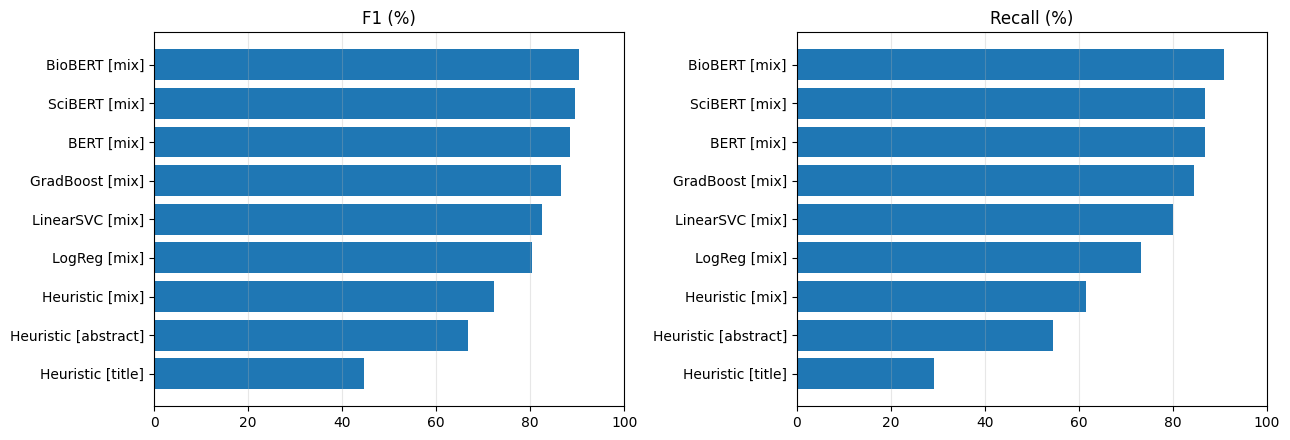

Đã lưu comparison.png


In [ ]:
# Cell 8b — Biểu đồ so sánh F1 / Recall
import matplotlib.pyplot as plt

plot_df = res_df.sort_values("f1")
fig, ax = plt.subplots(1, 2, figsize=(13, max(3, 0.5*len(plot_df))))
ax[0].barh(plot_df["model"], plot_df["f1"]);     ax[0].set_title("F1 (%)");     ax[0].set_xlim(0,100)
ax[1].barh(plot_df["model"], plot_df["recall"]); ax[1].set_title("Recall (%)"); ax[1].set_xlim(0,100)
for a in ax: a.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig("comparison.png", dpi=130, bbox_inches="tight"); plt.show()
print("Đã lưu comparison.png")

## 9. (Tuỳ chọn) Thí nghiệm sample-size — tái hiện Mục 3.2 của paper

Paper phát hiện: khi tăng kích thước train, **GB cải thiện rõ** nhưng **SciBERT gần như phẳng** (ổn định ngay cả với mẫu nhỏ). Cell này tái hiện ở quy mô nhỏ: train GB và SciBERT trên các kích thước {1k, 2k, 5k, 10k} và vẽ F1/Recall theo size.

> Cảnh báo: chạy SciBERT nhiều lần khá tốn thời gian. Bật `RUN_SIZE_EXPERIMENT = True` nếu bạn muốn.

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

  epoch 1/4 | train_loss 0.2943 | val_F1 87.67


  0%|          | 0/63 [00:00<?, ?it/s]

...

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/125 [00:00<?, ?it/s]

  epoch 4/4 | train_loss 0.0405 | val_F1 89.82


  0%|          | 0/125 [00:00<?, ?it/s]

size=10000: GB F1 86.0 | SciBERT F1 89.7


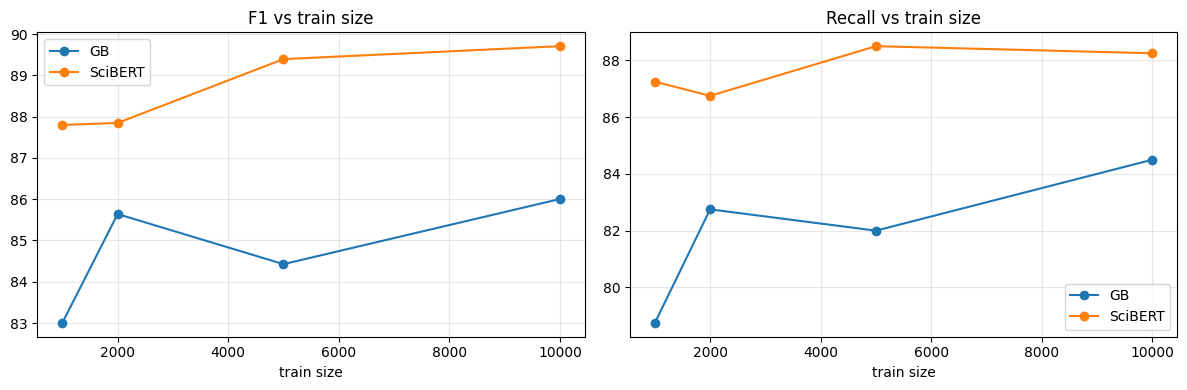

In [ ]:
# Cell 9 — Sample-size experiment (optional)
RUN_SIZE_EXPERIMENT = True #False   # đặt True để chạy

if RUN_SIZE_EXPERIMENT:
    sizes = [1000, 2000, 5000, 10000]
    size_rows = []
    full_train = train_df.reset_index(drop=True)

    for n in sizes:
        n = min(n, len(full_train))
        sub, _ = train_test_split(full_train, train_size=n/len(full_train),
                                  stratify=full_train["pubtype"], random_state=SEED)
        ys = sub["pubtype"].values

        # --- GB ---
        Xs = vec.transform([preprocess(t) for t in make_text(sub, CLASSICAL_TEXT)])
        gb = GradientBoostingClassifier(n_estimators=100).fit(Xs, ys)
        pgb = gb.predict(Xte)
        _, rgb, fgb, _ = (*precision_recall_fscore_support(y_test, pgb, average="binary", zero_division=0),)
        size_rows.append({"size": n, "model": "GB", "recall": rgb*100, "f1": fgb*100})

        # --- SciBERT ---
        globals()["train_texts"] = make_text(sub, BERT_TEXT)
        globals()["y_train"]     = ys
        yt, pt = fine_tune("allenai/scibert_scivocab_cased")
        _, rsb, fsb, _ = (*precision_recall_fscore_support(yt, pt, average="binary", zero_division=0),)
        size_rows.append({"size": n, "model": "SciBERT", "recall": rsb*100, "f1": fsb*100})
        print(f"size={n}: GB F1 {fgb*100:.1f} | SciBERT F1 {fsb*100:.1f}")

    sdf = pd.DataFrame(size_rows)
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    for m in ["GB","SciBERT"]:
        d = sdf[sdf.model==m]
        ax[0].plot(d["size"], d["f1"], marker="o", label=m)
        ax[1].plot(d["size"], d["recall"], marker="o", label=m)
    ax[0].set_title("F1 vs train size"); ax[1].set_title("Recall vs train size")
    for a in ax: a.set_xlabel("train size"); a.legend(); a.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig("size_experiment.png", dpi=130); plt.show()
else:
    print("Bỏ qua. Đặt RUN_SIZE_EXPERIMENT = True để chạy thí nghiệm Mục 3.2.")

## 10. Kết luận reproduce

**Tóm tắt những gì đã làm:**
1. Tải **full dataset gốc** (~500k records, Git LFS) tự động trong Cell 1.
2. Tái hiện đúng pipeline: làm sạch → split 80/10/10 stratified → 3 biến thể input (title/abstract/mix).
3. Cài đặt đủ **8 mô hình** như paper: heuristic, 3 ML cổ điển, (CNN có thể thêm), 3 BERT.
4. Đối chiếu xu hướng với bảng gốc và tái hiện thí nghiệm sample-size (Mục 3.2).

**Câu hỏi cần trả lời trong báo cáo (phần "hiểu paper"):**
- Vì sao BERT thắng chủ yếu ở **recall** chứ không phải precision? (gợi ý: ML cổ điển bỏ sót RCT diễn đạt không theo khuôn mẫu từ khoá; BERT nắm ngữ cảnh)
- Vì sao **BioBERT > SciBERT > BERT** trên dữ liệu y sinh? (miền pretraining)
- Trên subset của bạn, kết luận của paper có còn giữ không? Lệch ở đâu, vì sao?

> Nhắc lại giới hạn (chính tác giả thừa nhận): chỉ khảo sát 3 pretrained model, chưa thử RNN; dataset tuy lớn nhưng vẫn là subset của MEDLINE.
